In [1]:
import os
import shutil

os.chdir('/content')

if os.path.exists('/content/SelfBlendedImages'):
    print("Old folder found — removing it for a clean start...")
    shutil.rmtree('/content/SelfBlendedImages')

!git clone https://github.com/mapooon/SelfBlendedImages.git /content/SelfBlendedImages

os.chdir('/content/SelfBlendedImages')

!pip install timm segmentation-models-pytorch efficientnet_pytorch gdown -q

os.makedirs('/content/SelfBlendedImages/weights', exist_ok=True)

print("\n Cube 1 Done! Repo cloned and dependencies installed.")
print(f" Current directory: {os.getcwd()}")
print(f" Contents: {os.listdir('.')}")

Cloning into '/content/SelfBlendedImages'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 85 (delta 34), reused 31 (delta 30), pack-reused 35 (from 1)
Receiving objects: 100% (85/85), 1.54 MiB | 56.44 MiB/s, done.
Resolving deltas: 100% (36/36), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.2 MB/s eta 0:00:00

 Cube 1 Done! Repo cloned and dependencies installed.
 Current directory: /content/SelfBlendedImages
 Contents: ['LICENSE', 'weights', '.git', 'data', 'dockerfiles', 'README.md', 'exec.sh', 'src', 'overview.png', '.gitignore', 'build.sh']


In [2]:
import os
os.chdir('/content/SelfBlendedImages/weights')

# FFc23 weight file ID from the official README
!gdown "https://drive.google.com/uc?id=1X0-NYT8KPursLZZdxduRQju6E52hauV0" -O FFc23.tar

# Verify
if os.path.exists('FFc23.tar'):
    size = os.path.getsize('FFc23.tar') / (1024 * 1024)
    print(f"\n File size: {size:.1f} MB")
    if size > 50:
        print(" Cube 2 Done! FFc23.tar downloaded successfully.")
    else:
        print(" File too small — may be corrupted or download was blocked.")
else:
    print(" File not found — download failed.")

Downloading...
From (original): https://drive.google.com/uc?id=1X0-NYT8KPursLZZdxduRQju6E52hauV0
From (redirected): https://drive.google.com/uc?id=1X0-NYT8KPursLZZdxduRQju6E52hauV0&confirm=t&uuid=b42c7fec-b530-4655-a1f2-c94d0d2c5c8b
To: /content/SelfBlendedImages/weights/FFc23.tar
100% 141M/141M [00:05<00:00, 27.7MB/s]

 File size: 134.7 MB
 Cube 2 Done! FFc23.tar downloaded successfully.


In [3]:
import sys
import torch
import os

sys.path.append('/content/SelfBlendedImages/src')

from model import Detector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

weights_path = '/content/SelfBlendedImages/weights/FFc23.tar'

if not os.path.exists(weights_path):
    raise FileNotFoundError(f"Weights file missing: {weights_path}")

checkpoint = torch.load(weights_path, map_location=device)
print(f"\n Keys in checkpoint: {list(checkpoint.keys())}")

model = Detector().to(device)
model.load_state_dict(checkpoint['model'])
model.eval()

print(f"\n Cube 3 Done! Model loaded and ready on {device}.")

 Using device: cuda

 Keys in checkpoint: ['model', 'optimizer', 'epoch']
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b4-44fb3a87.pth" to /root/.cache/torch/hub/checkpoints/adv-efficientnet-b4-44fb3a87.pth


100%|██████████| 74.4M/74.4M [00:01<00:00, 43.1MB/s]

Loaded pretrained weights for efficientnet-b4

 Cube 3 Done! Model loaded and ready on cuda.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

local_zip = '/content/dfdc.zip'

if not os.path.exists(local_zip):
    print(" Copying from Google Drive...")
    shutil.copy('/content/drive/MyDrive/dfdc.zip', local_zip)
else:
    print(" Zip already exists locally, skipping.")

size = os.path.getsize(local_zip) / (1024 ** 3)
print(f"\n File size: {size:.2f} GB")
if size > 0.01:
    print(" Cube 4 Done! Dataset ready.")
else:
    print(" File too small — something went wrong.")

Mounted at /content/drive
 Copying from Google Drive...

 File size: 3.64 GB
 Cube 4 Done! Dataset ready.


In [5]:
import zipfile
import os

local_zip = '/content/dfdc.zip'
extract_to = '/content/custom_dataset'

if not os.path.exists(extract_to):
    print(" Extracting dataset...")
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(" Extraction complete!")
else:
    print(" Already extracted, skipping.")

for folder in ['fake', 'real']:
    folder_path = os.path.join(extract_to, 'validation', folder)
    if os.path.exists(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))])
        print(f" validation/{folder}/: {count} images")
    else:
        print(f" Folder not found: {folder_path}")

print("\n Cube 5 Done!")

 Extracting dataset...
 Extraction complete!
 validation/fake/: 24765 images
 validation/real/: 6029 images

 Cube 5 Done!


In [6]:
!pip install retinaface-pytorch -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 162.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 162.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 81.8 MB/s eta 0:00:00


In [7]:
import os
import sys
import cv2
import torch
import numpy as np
from tqdm import tqdm
import json

sys.path.append('/content/SelfBlendedImages/src/inference')

from model import Detector
from preprocess import crop_face
from retinaface.pre_trained_models import get_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load SBI model with FFc23 weights
weights_path = '/content/SelfBlendedImages/weights/FFc23.tar'
checkpoint = torch.load(weights_path, map_location=device)
model = Detector().to(device)
model.load_state_dict(checkpoint['model'])
model.eval()

# Load RetinaFace
face_detector = get_model("resnet50_2020-07-20", max_size=2048, device=device)
face_detector.eval()

def extract_face_safe(frame, model, image_size=(380, 380)):
    faces = model.predict_jsons(frame)
    if len(faces) == 0:
        return []
    croppedfaces = []
    for face in faces:
        bbox = face.get('bbox', [])
        if len(bbox) != 4:
            continue
        x0, y0, x1, y1 = bbox
        bbox_arr = np.array([[x0, y0], [x1, y1]])
        try:
            cropped = cv2.resize(
                crop_face(frame, None, bbox_arr, False, crop_by_bbox=True, only_img=True, phase='test'),
                dsize=image_size
            ).transpose((2, 0, 1))
            croppedfaces.append(cropped)
        except Exception:
            continue
    return croppedfaces

def predict_image(img_path):
    frame = cv2.imread(img_path)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    face_list = extract_face_safe(frame, face_detector)
    if len(face_list) == 0:
        return None
    with torch.no_grad():
        img = torch.from_numpy(np.array(face_list)).to(device).float() / 255
        pred = model(img).softmax(1)[:, 1].cpu().data.numpy().tolist()
    return max(pred)

results = {'fake': [], 'real': []}
skipped = {'fake': 0, 'real': 0}

for label in ['fake', 'real']:
    folder = f'/content/custom_dataset/validation/{label}'
    images = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))])
    print(f"\n Running inference on {len(images)} {label} images...")
    for img_name in tqdm(images):
        img_path = os.path.join(folder, img_name)
        prob = predict_image(img_path)
        if prob is None:
            skipped[label] += 1
        else:
            results[label].append(prob)

    # Save after each label
    with open('/content/drive/MyDrive/FFc23_dfdc_results.json', 'w') as f:
        json.dump({'results': {'fake': results['fake'], 'real': results['real']}, 'skipped': skipped}, f)
    print(f" Saved results to Drive!")

print(f"\n Cube 7 Done!")
print(f" Skipped (no face detected): fake={skipped['fake']}, real={skipped['real']}")

Loaded pretrained weights for efficientnet-b4


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/ternaus/retinaface/releases/download/0.01/retinaface_resnet50_2020-07-20-f168fae3c.zip" to /root/.cache/torch/hub/checkpoints/retinaface_resnet50_2020-07-20-f168fae3c.zip


100%|██████████| 96.9M/96.9M [00:00<00:00, 658MB/s]
/usr/local/lib/python3.12/dist-packages/torch/hub.py:897: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zip_load(cached_file, model_dir, map_location, weights_only)



 Running inference on 24765 fake images...


100%|██████████| 24765/24765 [50:24<00:00,  8.19it/s]


 Saved results to Drive!

 Running inference on 6029 real images...


100%|██████████| 6029/6029 [12:16<00:00,  8.19it/s]

 Saved results to Drive!

 Cube 7 Done!
 Skipped (no face detected): fake=5334, real=1213


In [8]:
import numpy as np
import json

threshold = 0.5

fake_probs = np.array(results['fake'])
real_probs = np.array(results['real'])

# Predictions
fake_correct = np.sum(fake_probs > threshold)
real_correct = np.sum(real_probs <= threshold)

fake_total = len(fake_probs)
real_total = len(real_probs)
total = fake_total + real_total

print("=" * 45)
print("   FFc23 Results on DFDC Validation")
print("=" * 45)
print(f"\n Fake images:  {fake_correct}/{fake_total} correctly detected ({100*fake_correct/fake_total:.2f}%)")
print(f" Real images:  {real_correct}/{real_total} correctly detected ({100*real_correct/real_total:.2f}%)")
print(f"\n Overall accuracy: {100*(fake_correct+real_correct)/total:.2f}%")
print(f"\n Avg fake score on fake images: {fake_probs.mean():.4f}")
print(f" Avg fake score on real images: {real_probs.mean():.4f}")
print(f"\n  Skipped (no face detected): fake={skipped['fake']}, real={skipped['real']}")
print("=" * 45)

# Save to Drive
save_path = '/content/drive/MyDrive/FFraw_dfdc_results.json'
with open(save_path, 'w') as f:
    json.dump({'results': {'fake': fake_probs.tolist(), 'real': real_probs.tolist()}, 'skipped': skipped}, f)
print(f"\n Results saved to Drive!")

   FFc23 Results on DFDC Validation

 Fake images:  3834/19431 correctly detected (19.73%)
 Real images:  4503/4816 correctly detected (93.50%)

 Overall accuracy: 34.38%

 Avg fake score on fake images: 0.3293
 Avg fake score on real images: 0.2557

  Skipped (no face detected): fake=5334, real=1213

 Results saved to Drive!


In [9]:
from sklearn.metrics import roc_auc_score
import numpy as np

labels = [1] * len(fake_probs) + [0] * len(real_probs)
scores = list(fake_probs) + list(real_probs)

auc = roc_auc_score(labels, scores)
print(f" AUC-ROC: {auc:.4f}")

 AUC-ROC: 0.5949


Calculating Bootstrap CI...
AUC: 0.5949 (95% CI: [0.5870, 0.6029])


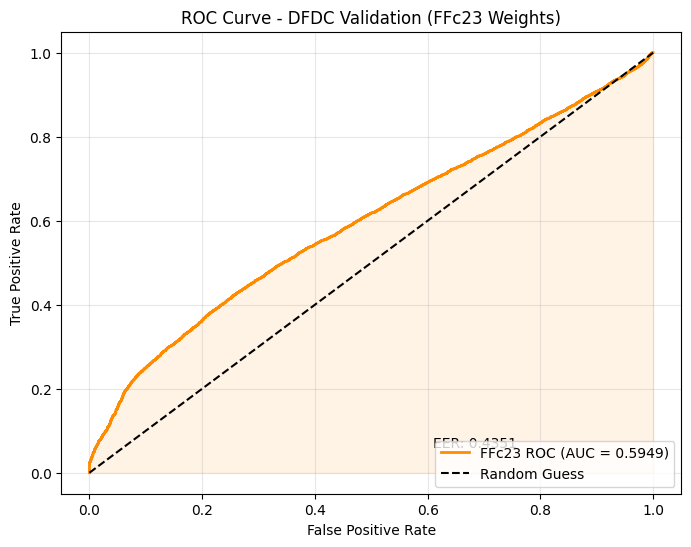

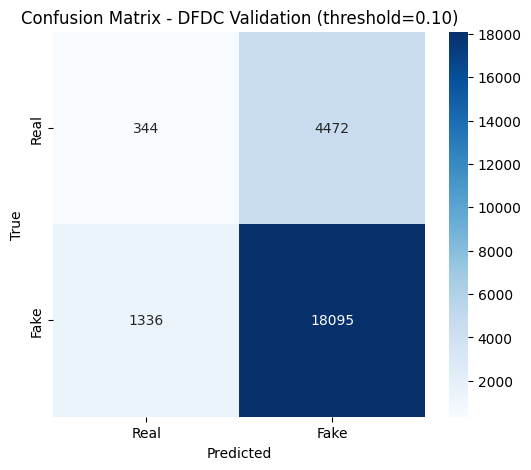

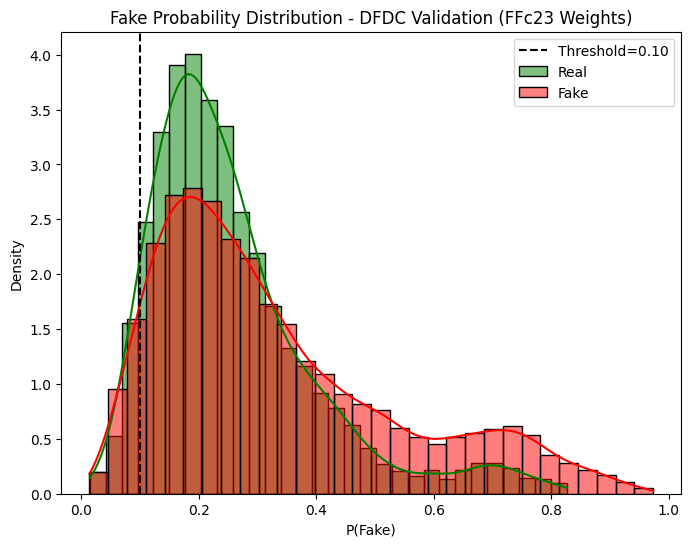


 Graphs saved to: /content/drive/MyDrive/Deepfake_Project/Graphs_FFc23_DFDC


In [10]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score, accuracy_score

all_probs  = np.array(list(fake_probs) + list(real_probs))
all_labels = np.array([1] * len(fake_probs) + [0] * len(real_probs))

graph_dir = '/content/drive/MyDrive/Deepfake_Project/Graphs_FFc23_DFDC'
os.makedirs(graph_dir, exist_ok=True)
rng = np.random.RandomState(42)

# Best threshold
thresholds = np.arange(0.1, 0.91, 0.01)
best_thresh = thresholds[np.argmax([accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds])]

# 1. Bootstrap CI
print('Calculating Bootstrap CI...')
bootstrapped_aucs = []
for _ in range(1000):
    idx = rng.randint(0, len(all_probs), len(all_probs))
    if len(np.unique(all_labels[idx])) < 2:
        continue
    bootstrapped_aucs.append(roc_auc_score(all_labels[idx], all_probs[idx]))
sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f'AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])')

# 2. ROC Curve + EER
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fnr = 1 - tpr
eer = (fpr[np.argmin(np.abs(fpr - fnr))] + fnr[np.argmin(np.abs(fpr - fnr))]) / 2
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'FFc23 ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DFDC Validation (FFc23 Weights)')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(all_labels, (all_probs >= best_thresh).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion Matrix - DFDC Validation (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# 4. Probability Distribution
plt.figure(figsize=(8, 6))
sns.histplot(real_probs, color='green', label='Real', kde=True, stat='density', alpha=0.5, bins=30)
sns.histplot(fake_probs, color='red',   label='Fake', kde=True, stat='density', alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)'); plt.ylabel('Density')
plt.title('Fake Probability Distribution - DFDC Validation (FFc23 Weights)')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'\n Graphs saved to: {graph_dir}')